### DATASET PREVIEW ###


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4



### DATA TYPES AND NULL VALUES ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None

### STATISTICAL SUMMARY ###


,total_bill,tip,sex,smoker,day,time,size
count,244.000000,244.000000,244,244,244,244,244.000000
unique,NaN,NaN,2,2,4,2,NaN
top,NaN,NaN,Male,No,Sat,Dinner,NaN
freq,NaN,NaN,157,151,87,176,NaN
mean,19.785943,2.998279,NaN,NaN,NaN,NaN,2.569672
std,8.902412,1.383638,NaN,NaN,NaN,NaN,0.951100
min,3.070000,1.000000,NaN,NaN,NaN,NaN,1.000000
25%,13.347500,2.000000,NaN,NaN,NaN,NaN,2.000000
50%,17.795000,2.900000,NaN,NaN,NaN,NaN,2.000000
75%,24.127500,3.562500,NaN,NaN,NaN,NaN,3.000000


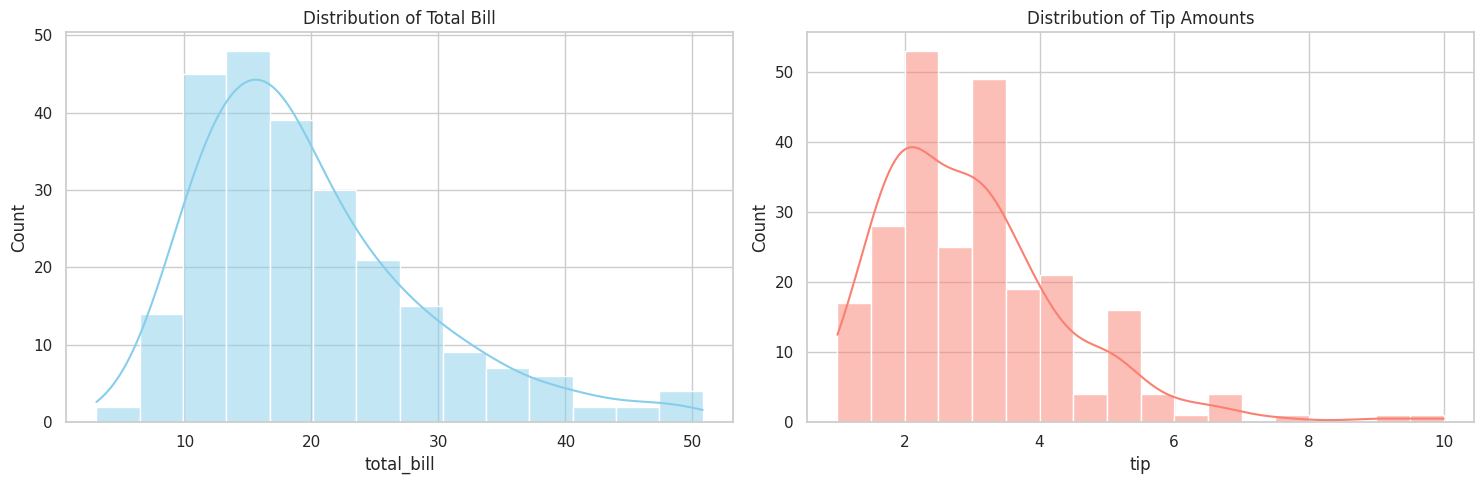

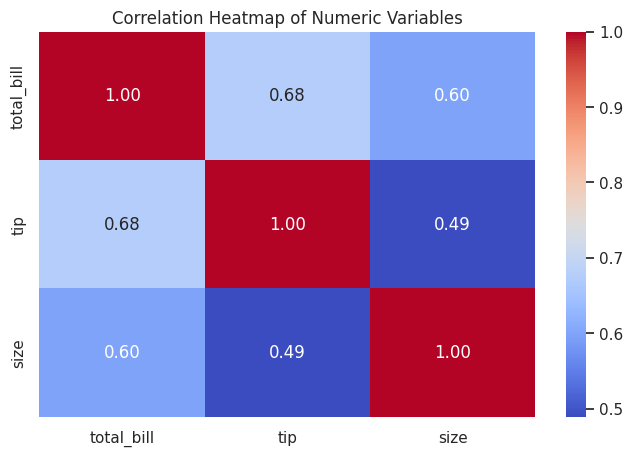

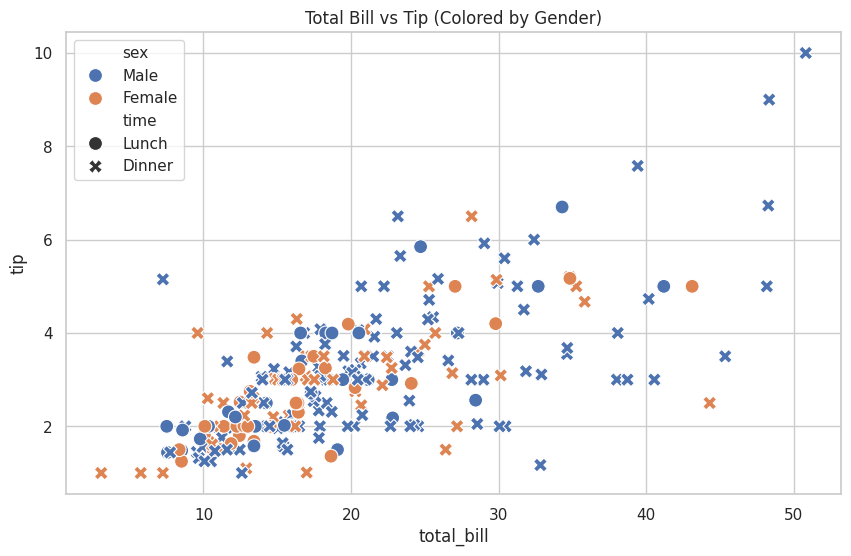

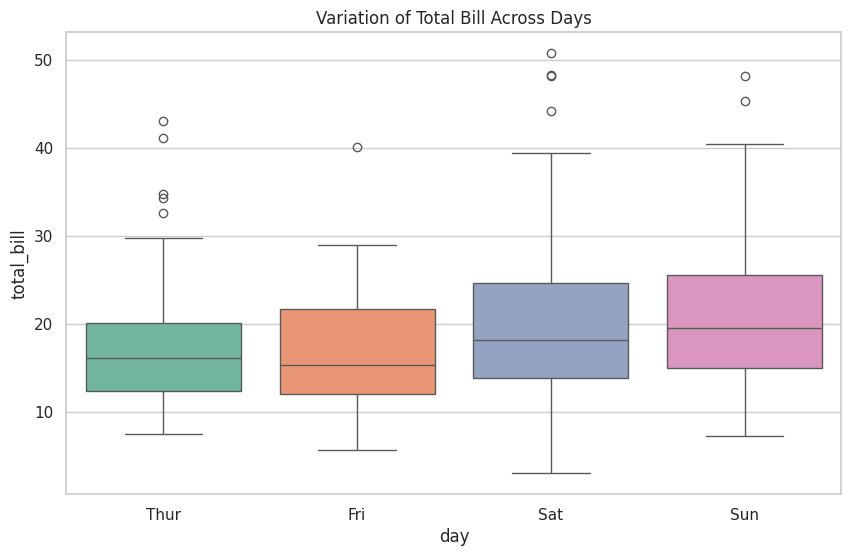

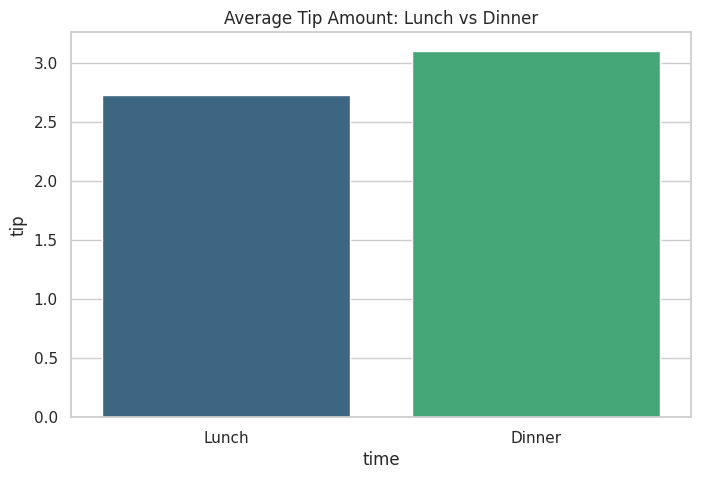


--- KEY INSIGHTS ---
1. Total entries: 244
2. Average Tip: $3.00
3. Most frequent day for dining: Sat
4. Correlation between Bill and Tip: 0.68


In [1]:
# ==========================================
# 1. SETUP AND DATA LOADING
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import data_table

# Enable interactive tables for Colab
data_table.enable_dataframe_formatter()

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load dataset (Built-in Seaborn dataset for zero-error execution)
df = sns.load_dataset('tips')

# ==========================================
# 2. INITIAL DATA EXPLORATION
# ==========================================
print("### DATASET PREVIEW ###")
display(df.head())

print("\n### DATA TYPES AND NULL VALUES ###")
print(df.info())

print("\n### STATISTICAL SUMMARY ###")
display(df.describe(include='all'))

# ==========================================
# 3. UNIVARIATE ANALYSIS (Individual Variables)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribution of Total Bill
sns.histplot(df['total_bill'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Total Bill')

# Distribution of Tips
sns.histplot(df['tip'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Tip Amounts')

plt.tight_layout()
plt.show()

# ==========================================
# 4. MULTIVARIATE ANALYSIS (Correlations & Relationships)
# ==========================================
# A. Correlation Heatmap (Numeric only)
plt.figure(figsize=(8, 5))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()

# B. Relationship: Bill vs Tip (Categorized by Gender)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='total_bill', y='tip', hue='sex', style='time', s=100)
plt.title('Total Bill vs Tip (Colored by Gender)')
plt.show()

# ==========================================
# 5. CATEGORICAL INSIGHTS & INFLUENCING FACTORS
# ==========================================
# C. How much do different days impact the bill?
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='day', y='total_bill', palette='Set2', hue='day', legend=False)
plt.title('Variation of Total Bill Across Days')
plt.show()

# D. Average Tip by Time of Day
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='time', y='tip', estimator=np.mean, errorbar=None, palette='viridis', hue='time', legend=False)
plt.title('Average Tip Amount: Lunch vs Dinner')
plt.show()

# ==========================================
# 6. SUMMARY INSIGHTS
# ==========================================
print("\n--- KEY INSIGHTS ---")
print(f"1. Total entries: {len(df)}")
print(f"2. Average Tip: ${df['tip'].mean():.2f}")
print(f"3. Most frequent day for dining: {df['day'].mode()[0]}")
print(f"4. Correlation between Bill and Tip: {df['total_bill'].corr(df['tip']):.2f}")